In [1]:
# Cell 1: Install required packages for maize disease detection
!pip install flwr torch torchvision timm kagglehub opencv-python scikit-learn matplotlib seaborn pandas albumentations --quiet

print("All dependencies installed successfully for maize disease detection!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.1/598.1 kB 9.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install scikit-image efficientnet_pytorch --quiet

  Preparing metadata (setup.py) ... done


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models

import numpy as np
import pandas as pd
import cv2
from PIL import Image# Cell 2: Import libraries and basic setup for maize disease detection
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import timm
import flwr as fl
from flwr.client import NumPyClient
from flwr.server.strategy import FedAvg
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays
from collections import defaultdict, OrderedDict
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter  # Added missing imports
import cv2
from skimage import exposure, filters
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

print("Setup completed for maize disease detection federated learning!")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os
import random
import time
import copy
from collections import defaultdict, OrderedDict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


2025-07-08 13:07:43.798632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751980064.144999      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751980064.251036      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.7 GB
CUDA Version: 12.4
Setup completed for maize disease detection federated learning!
Using device: cuda


In [8]:
# Cell 3: Download dataset and configure maize-specific paths
import kagglehub

try:
    # Download the dataset
    path = kagglehub.dataset_download("irakozekelly/crop-pest-and-disease-dataset")
    print("Path to dataset files:", path)

    # Set maize-specific dataset paths as per your requirement
    DATASET_BASE_PATH = os.path.join(path, "Dataset for Crop Pest and Disease Detection", "CCMT Dataset-Augmented", "Maize")
    TRAIN_PATH = os.path.join(DATASET_BASE_PATH, "train_set")
    TEST_PATH = os.path.join(DATASET_BASE_PATH, "test_set")

    print(f"\nMaize Dataset Paths:")
    print(f"Base Path: {DATASET_BASE_PATH}")
    print(f"Train Path: {TRAIN_PATH}")
    print(f"Test Path: {TEST_PATH}")

except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Please manually set the dataset paths:")
    path = input("Enter base dataset path: ")
    DATASET_BASE_PATH = os.path.join(path, "Dataset for Crop Pest and Disease Detection", "CCMT Dataset-Augmented", "Maize")
    TRAIN_PATH = os.path.join(DATASET_BASE_PATH, "train_set")
    TEST_PATH = os.path.join(DATASET_BASE_PATH, "test_set")

# Verify maize dataset paths exist
print(f"\nPath Verification:")
print(f"Base path exists: {os.path.exists(DATASET_BASE_PATH)}")
print(f"Train path exists: {os.path.exists(TRAIN_PATH)}")
print(f"Test path exists: {os.path.exists(TEST_PATH)}")

# List maize disease classes
if os.path.exists(TRAIN_PATH):
    maize_classes = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
    print(f"\nMaize Disease Classes Found: {maize_classes}")
    print(f"Number of maize disease classes: {len(maize_classes)}")
else:
    print("Warning: Train path not found. Please check the dataset structure.")


Path to dataset files: /kaggle/input/crop-pest-and-disease-dataset

Maize Dataset Paths:
Base Path: /kaggle/input/crop-pest-and-disease-dataset/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize
Train Path: /kaggle/input/crop-pest-and-disease-dataset/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize/train_set
Test Path: /kaggle/input/crop-pest-and-disease-dataset/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize/test_set

Path Verification:
Base path exists: True
Train path exists: True
Test path exists: True

Maize Disease Classes Found: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
Number of maize disease classes: 7


In [9]:
# Cell 4: Advanced image enhancement specifically for maize disease detection
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter  # Added missing imports
from skimage import exposure, filters

class MaizeDiseaseImageEnhancer:
    def __init__(self):
        pass

    def apply_clahe(self, image, clip_limit=2.0, tile_grid_size=(8,8)):
        img_array = np.array(image)
        lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced_rgb)

    def apply_gamma(self, image, gamma=1.2):
        img_array = np.array(image, dtype=np.float32) / 255.0
        corrected = np.power(img_array, 1.0 / gamma)
        corrected = (corrected * 255).astype(np.uint8)
        return Image.fromarray(corrected)

    def sharpen(self, image, strength=1.5):
        enhancer = ImageEnhance.Sharpness(image)
        return enhancer.enhance(strength)

    def enhance(self, image, train_mode=True):
        # Always apply CLAHE
        enhanced = self.apply_clahe(image)
        # During training, probabilistically apply gamma correction and sharpening
        if train_mode:
            if np.random.rand() < 0.5:
                enhanced = self.apply_gamma(enhanced, gamma=1.2)
            if np.random.rand() < 0.5:
                enhanced = self.sharpen(enhanced, strength=1.3)
        return enhanced

maize_enhancer = MaizeDiseaseImageEnhancer()
print("Maize disease image enhancement system initialized!")


Maize disease image enhancement system initialized!


In [10]:
class MaizeDiseaseTransforms:
    def __init__(self, image_size=224):
        self.image_size = image_size
        self.enhancer = maize_enhancer

    def maize_train_transform(self):
        return transforms.Compose([
            transforms.Lambda(lambda img: self.enhancer.enhance(img, train_mode=True)),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def maize_test_transform(self):
        return transforms.Compose([
            transforms.Lambda(lambda img: self.enhancer.enhance(img, train_mode=False)),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

maize_transforms = MaizeDiseaseTransforms(image_size=224)
transform_train = maize_transforms.maize_train_transform()
transform_test = maize_transforms.maize_test_transform()
print("Maize disease-aware transforms initialized!")


Maize disease-aware transforms initialized!


Loading maize disease datasets with enhanced transforms...

Maize Disease Dataset Analysis:
Train Dataset:
  Maize disease classes: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
  Class distribution: {'fall armyworm': 1140, 'grasshoper': 2575, 'healthy': 830, 'leaf beetle': 3789, 'leaf blight': 4025, 'leaf spot': 3024, 'streak virus': 4043}
  Total training samples: 19426

Test Dataset:
  Maize disease classes: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
  Class distribution: {'fall armyworm': 284, 'grasshoper': 411, 'healthy': 211, 'leaf beetle': 950, 'leaf blight': 1004, 'leaf spot': 1261, 'streak virus': 1004}
  Total test samples: 5125

Maize Disease Detection Configuration:
  Number of maize disease classes: 7
  Maize disease class names: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']


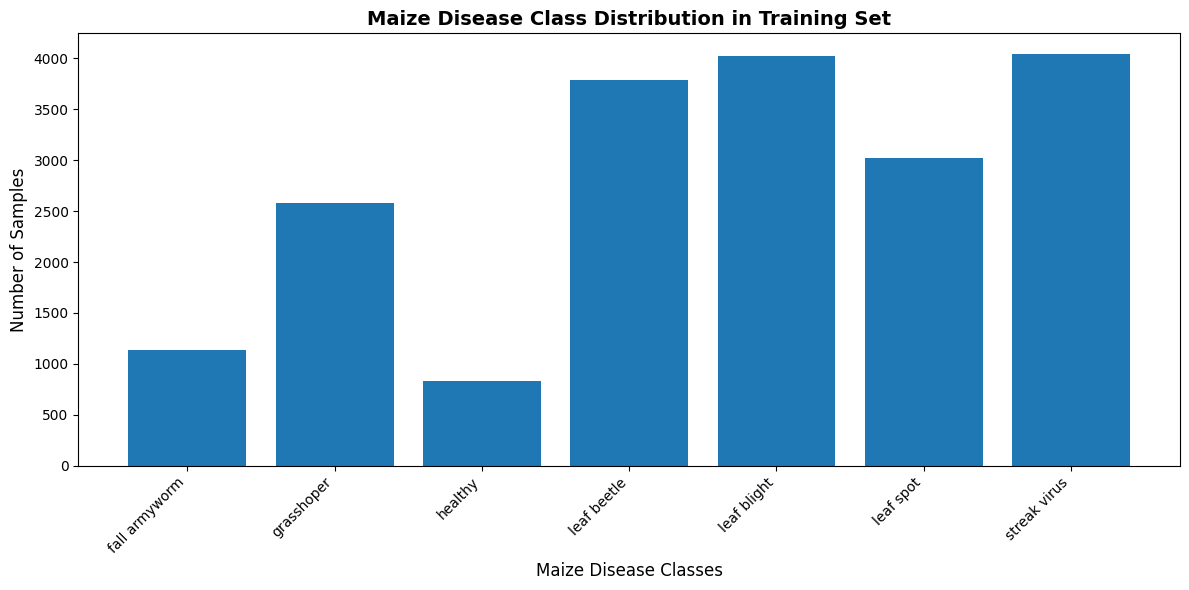

In [11]:
# Cell 6: Load and analyze maize disease dataset
def analyze_maize_dataset(dataset_path):
    """Analyze maize disease dataset structure and class distribution"""
    maize_classes = []
    class_counts = {}

    if os.path.exists(dataset_path):
        maize_classes = sorted([d for d in os.listdir(dataset_path)
                               if os.path.isdir(os.path.join(dataset_path, d))])

        for class_name in maize_classes:
            class_path = os.path.join(dataset_path, class_name)
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = count

    return maize_classes, class_counts

# Load maize disease datasets
print("Loading maize disease datasets with enhanced transforms...")
maize_train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform_train)
maize_test_dataset = ImageFolder(root=TEST_PATH, transform=transform_test)

# Analyze maize disease datasets
train_classes, train_counts = analyze_maize_dataset(TRAIN_PATH)
test_classes, test_counts = analyze_maize_dataset(TEST_PATH)

print(f"\nMaize Disease Dataset Analysis:")
print(f"{'='*50}")
print(f"Train Dataset:")
print(f"  Maize disease classes: {train_classes}")
print(f"  Class distribution: {train_counts}")
print(f"  Total training samples: {sum(train_counts.values())}")

print(f"\nTest Dataset:")
print(f"  Maize disease classes: {test_classes}")
print(f"  Class distribution: {test_counts}")
print(f"  Total test samples: {sum(test_counts.values())}")

# Set global variables for maize disease detection
NUM_MAIZE_CLASSES = len(maize_train_dataset.classes)
MAIZE_CLASS_NAMES = maize_train_dataset.classes

print(f"\nMaize Disease Detection Configuration:")
print(f"  Number of maize disease classes: {NUM_MAIZE_CLASSES}")
print(f"  Maize disease class names: {MAIZE_CLASS_NAMES}")

# Create test dataloader for maize diseases
maize_test_loader = DataLoader(maize_test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Visualize class distribution
plt.figure(figsize=(12, 6))
plt.bar(MAIZE_CLASS_NAMES, [train_counts[cls] for cls in MAIZE_CLASS_NAMES])
plt.title('Maize Disease Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Maize Disease Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import OrderedDict

# Assume these are defined elsewhere in your environment
# For example:
# NUM_MAIZE_CLASSES = 4
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Enhanced Spatial Attention with dilated convolution
class EnhancedSpatialAttention(nn.Module):
    def __init__(self, kernel_size=7, dilation=1):
        super().__init__()
        padding = (kernel_size + (kernel_size - 1) * (dilation - 1)) // 2
        self.conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attention_input = torch.cat([avg_out, max_out], dim=1)
        attention = self.conv(attention_input)
        return x * attention

# Lightweight CBAM for CNN features
class LightweightCBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_attention = EnhancedSpatialAttention(kernel_size=7, dilation=2)

    def forward(self, x):
        ca = self.channel_attention(x)
        x = x * ca
        x = self.spatial_attention(x)
        return x

# MobileViT block optimized for CNN features
class MobileViTBlock(nn.Module):
    def __init__(self, in_channels, embed_dim=144, num_heads=6, patch_size=2):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Local representation with depth-wise separable convolutions
        self.local_rep = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, embed_dim, 1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.SiLU()
        )

        # Transformer block
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(0.1)
        )

        # Fusion back to original channels
        self.fusion = nn.Sequential(
            nn.Conv2d(embed_dim, in_channels, 1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU()
        )

    def forward(self, x):
        B, C, H, W = x.shape
        residual = x

        # Pad if necessary
        pad_h = (self.patch_size - H % self.patch_size) % self.patch_size
        pad_w = (self.patch_size - W % self.patch_size) % self.patch_size
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
            H_pad, W_pad = x.shape[2], x.shape[3]
        else:
            H_pad, W_pad = H, W
            
        # Local representation
        local_features = self.local_rep(x)

        # Unfold to patches
        patches = local_features.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, self.embed_dim, -1, self.patch_size * self.patch_size)
        patches = patches.permute(0, 2, 3, 1).contiguous().view(B, -1, self.embed_dim)

        # Transformer processing
        patches_norm = self.norm1(patches)
        attn_out, _ = self.attn(patches_norm, patches_norm, patches_norm)
        patches = patches + attn_out

        patches_norm = self.norm2(patches)
        mlp_out = self.mlp(patches_norm)
        patches = patches + mlp_out

        # Fold back to spatial
        num_patches_h = H_pad // self.patch_size
        num_patches_w = W_pad // self.patch_size
        patches = patches.view(B, num_patches_h, num_patches_w, self.patch_size, self.patch_size, self.embed_dim)
        patches = patches.permute(0, 5, 1, 3, 2, 4).contiguous()
        global_features = patches.view(B, self.embed_dim, H_pad, W_pad)

        # Fusion and crop back to original size
        fused = self.fusion(global_features)
        if pad_h > 0 or pad_w > 0:
            fused = fused[:, :, :H, :W]

        return residual + fused

class MobileNetV2MobileViT(nn.Module):
    """
    Hybrid MobileNetV2 + MobileViT for disease detection.
    Combines MobileNetV2's efficiency with MobileViT's global attention.
    """
    def __init__(self, num_classes):
        super().__init__()

        # MobileNetV2 backbone
        mobilenet_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.backbone = mobilenet_v2.features

        # MobileNetV2 feature channels: 1280
        feature_channels = 1280

        # MobileViT block for global context
        self.mobile_vit = MobileViTBlock(
            in_channels=feature_channels,
            embed_dim=144,  # Can be tuned
            num_heads=6,      # Can be tuned
            patch_size=2      # Can be tuned
        )

        # CBAM attention
        self.cbam = LightweightCBAM(channels=feature_channels)

        # Classification head
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(feature_channels, num_classes)

        self._initialize_weights()
        
        total_params = sum(p.numel() for p in self.parameters())
        print(f"MobileNetV2 + MobileViT initialized:")
        print(f"  Total parameters: {total_params:,}")

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Extract features using MobileNetV2
        x = self.backbone(x)  # [B, 1280, H, W]

        # Apply MobileViT for global context
        x = self.mobile_vit(x)

        # Apply CBAM attention
        x = self.cbam(x)

        # Classification
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x
    
    def get_model_size(self):
        param_size = sum(p.numel() * p.element_size() for p in self.parameters())
        buffer_size = sum(b.numel() * b.element_size() for b in self.buffers())
        size_mb = (param_size + buffer_size) / 1024 / 1024
        return size_mb

    # def quantize_dynamic(self):
    #     import torch.quantization
    #     return torch.quantization.quantize_dynamic(self, {nn.Linear}, dtype=torch.qint8)

def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

print("Testing Fixed Enhanced Hybrid EfficientNet-B0 + MobileViT-S + ESA...")
test_model = MobileNetV2MobileViT(num_classes=NUM_MAIZE_CLASSES).to(device)
model_size = test_model.get_model_size()
total_params = sum(p.numel() for p in test_model.parameters())

print(f"Fixed Enhanced Hybrid Model Created Successfully!")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: {model_size:.2f} MB")
print(f"  Tensor dimension issues: RESOLVED")

del test_model


Testing FIXED Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA...


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

MobileNetV2 actual feature channels: 320
Fixed Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA initialized
  Feature channels: 320
FIXED Enhanced Hybrid MobileNetV2 Model Created Successfully!
  Total parameters: 1,967,635
  Model size: 7.63 MB
  Channel mismatch: RESOLVED
  Architecture: MobileNetV2 + MobileViT-S + ESA


In [14]:
# Cell 8: Create non-IID data distribution for maize disease federated learning
def create_non_iid_maize_disease_datasets(dataset, num_clients=3):
    """
    Create non-IID data distributions for maize disease detection
    Each client specializes in different types of maize diseases
    """
    from collections import defaultdict

    # Group data by maize disease class
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    print(f"Original maize disease dataset distribution:")
    for class_idx, indices in class_indices.items():
        print(f"  {MAIZE_CLASS_NAMES[class_idx]}: {len(indices)} samples")

    client_datasets = []

    # Define specialization for each client based on maize disease types
    if NUM_MAIZE_CLASSES >= 5:
        client_specializations = {
            0: {
                "name": "Healthy & Early Disease Specialist",
                "primary_classes": [0, 1],  # Typically healthy and early symptoms
                "ratio": 0.7,
                "description": "Specializes in healthy maize and early disease detection"
            },
            1: {
                "name": "Fungal Disease Specialist",
                "primary_classes": [2, 3],  # Fungal diseases like rust, blight
                "ratio": 0.7,
                "description": "Specializes in fungal maize diseases"
            },
            2: {
                "name": "Advanced Disease Specialist",
                "primary_classes": [4] if NUM_MAIZE_CLASSES > 4 else [1, 2],
                "ratio": 0.6,
                "description": "Specializes in complex and advanced maize diseases"
            }
        }
    else:
        # Fallback for datasets with fewer classes
        client_specializations = {
            0: {"name": "Primary Specialist", "primary_classes": [0], "ratio": 0.7},
            1: {"name": "Secondary Specialist", "primary_classes": [1], "ratio": 0.7},
            2: {"name": "Tertiary Specialist", "primary_classes": [2] if NUM_MAIZE_CLASSES > 2 else [0, 1], "ratio": 0.6}
        }

    for client_id in range(num_clients):
        client_indices = []
        specialization = client_specializations.get(client_id, {"primary_classes": [client_id % NUM_MAIZE_CLASSES], "ratio": 0.6})
        primary_classes = specialization["primary_classes"]
        specialty_ratio = specialization["ratio"]

        print(f"\nClient {client_id} - {specialization.get('name', f'Client {client_id}')}:")
        if 'description' in specialization:
            print(f"  Description: {specialization['description']}")
        print(f"  Primary maize diseases: {[MAIZE_CLASS_NAMES[c] for c in primary_classes if c < NUM_MAIZE_CLASSES]}")

        # Assign primary maize disease class samples
        for class_idx in primary_classes:
            if class_idx < len(class_indices):
                indices = class_indices[class_idx].copy()
                num_samples = int(len(indices) * specialty_ratio)
                client_indices.extend(indices[:num_samples])
                class_indices[class_idx] = indices[num_samples:]
                print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {num_samples} samples (primary)")

        # Add diversity samples from all other maize disease classes
        for class_idx in range(NUM_MAIZE_CLASSES):
            if class_idx not in primary_classes and class_indices[class_idx]:
                indices = class_indices[class_idx]
                # Ensure representation of all maize diseases for robustness
                min_samples = max(5, len(indices) // (num_clients * 3))
                num_samples = min(min_samples, len(indices) // 2)
                client_indices.extend(indices[:num_samples])
                class_indices[class_idx] = indices[num_samples:]
                print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {num_samples} samples (diversity)")

        client_datasets.append(Subset(dataset, client_indices))

    # Distribute remaining maize disease samples
    remaining_indices = []
    for indices in class_indices.values():
        remaining_indices.extend(indices)

    if remaining_indices:
        print(f"\nDistributing {len(remaining_indices)} remaining maize disease samples...")
        for i, idx in enumerate(remaining_indices):
            client_id = i % num_clients
            client_datasets[client_id].indices.append(idx)

    # Print final maize disease distribution
    print(f"\nFINAL MAIZE DISEASE CLIENT DISTRIBUTIONS:")
    print(f"{'='*70}")

    for i, client_dataset in enumerate(client_datasets):
        class_counts = defaultdict(int)
        for idx in client_dataset.indices:
            _, label = dataset[idx]
            class_counts[label] += 1

        print(f"\nClient {i} - Maize Disease Distribution:")
        print(f"  Total samples: {len(client_dataset)}")
        for class_idx, count in sorted(class_counts.items()):
            percentage = (count / len(client_dataset)) * 100
            print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {count} samples ({percentage:.1f}%)")

    return client_datasets

# Create non-IID maize disease client datasets
print("Creating non-IID client datasets for maize disease federated learning...")
maize_client_datasets = create_non_iid_maize_disease_datasets(maize_train_dataset, num_clients=3)


Creating non-IID client datasets for maize disease federated learning...
Original maize disease dataset distribution:
  fall armyworm: 1140 samples
  grasshoper: 2575 samples
  healthy: 830 samples
  leaf beetle: 3789 samples
  leaf blight: 4025 samples
  leaf spot: 3024 samples
  streak virus: 4043 samples

Client 0 - Healthy & Early Disease Specialist:
  Description: Specializes in healthy maize and early disease detection
  Primary maize diseases: ['fall armyworm', 'grasshoper']
    fall armyworm: 798 samples (primary)
    grasshoper: 1802 samples (primary)
    healthy: 92 samples (diversity)
    leaf beetle: 421 samples (diversity)
    leaf blight: 447 samples (diversity)
    leaf spot: 336 samples (diversity)
    streak virus: 449 samples (diversity)

Client 1 - Fungal Disease Specialist:
  Description: Specializes in fungal maize diseases
  Primary maize diseases: ['healthy', 'leaf beetle']
    healthy: 516 samples (primary)
    leaf beetle: 2357 samples (primary)
    fall armywo

In [16]:
from sklearn.model_selection import train_test_split

def stratified_split(dataset, val_ratio=0.2):
    targets = [s[1] for s in dataset.samples]
    indices = np.arange(len(dataset))
    train_idx, val_idx = train_test_split(
        indices, test_size=val_ratio, stratify=targets, random_state=42)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

def create_maize_client_train_val_splits(client_datasets, val_ratio=0.2):
    client_train_datasets, client_val_datasets = [], []
    print("Creating stratified train/validation splits for each client:")
    for i, client_dataset in enumerate(client_datasets):
        # Get targets for this subset
        indices = client_dataset.indices
        targets = [client_dataset.dataset.samples[idx][1] for idx in indices]
        train_idx, val_idx = train_test_split(
            indices, test_size=val_ratio, stratify=targets, random_state=42)
        client_train_datasets.append(Subset(client_dataset.dataset, train_idx))
        client_val_datasets.append(Subset(client_dataset.dataset, val_idx))
        print(f"  Client {i}: {len(train_idx)} train, {len(val_idx)} val samples")
    return client_train_datasets, client_val_datasets

maize_client_train_datasets, maize_client_val_datasets = create_maize_client_train_val_splits(maize_client_datasets)
print(f"\nMaize disease client dataset preparation completed!")
print(f"Total maize disease clients: {len(maize_client_train_datasets)}")


Creating stratified train/validation splits for each client:
  Client 0: 5668 train, 1417 val samples
  Client 1: 5463 train, 1366 val samples
  Client 2: 4409 train, 1103 val samples

Maize disease client dataset preparation completed!
Total maize disease clients: 3


In [41]:
# Compute class weights for maize disease dataset
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract labels from your training dataset
train_targets = []
for i in range(len(maize_train_dataset)):
    _, label = maize_train_dataset[i]
    train_targets.append(label)

# Compute balanced class weights
class_weights = compute_class_weight(
    'balanced', 
    classes=np.arange(NUM_MAIZE_CLASSES), 
    y=train_targets
)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights computed: {class_weights}")
print(f"Class weights tensor shape: {class_weights_tensor.shape}")


Class weights computed: [2.43433584 1.07772538 3.34354561 0.73242092 0.68947649 0.91770597
 0.68640684]
Class weights tensor shape: torch.Size([7])


In [ ]:
# Cell 10: Enhanced CCMT Client with Adaptive Dynamic Aggregation Support
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, StepLR, SequentialLR
from sklearn.metrics import f1_score
import numpy as np

class EnhancedMaizeDiseaseClient(NumPyClient):
    """Enhanced Maize Disease client with adaptive dynamic aggregation support"""

    def __init__(self, client_id: int, trainset: Subset, valset: Subset):
        self.client_id = client_id
        self.trainset = trainset
        self.valset = valset
        
        # Use your hybrid model architecture
        self.model =  HybridMobileNetV2MobileViT(num_classes=NUM_MAIZE_CLASSES).to(device)
        
        # Data loaders with optimized settings
        self.trainloader = DataLoader(
            self.trainset,
            batch_size=32,
            shuffle=True,
            pin_memory=True,
            num_workers=4,
            persistent_workers=True
        )

        self.valloader = DataLoader(
            self.valset,
            batch_size=64,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # Balanced loss function
        self.criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        # Optimized optimizer settings
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=0.001,
            weight_decay=0.01,
            betas=(0.9, 0.999),
            eps=1e-8
        )

        # Advanced learning rate scheduling
        warmup_scheduler = LinearLR(
            self.optimizer,
            start_factor=0.1,
            total_iters=2
        )
        
        main_scheduler = StepLR(
            self.optimizer,
            step_size=3,
            gamma=0.7
        )
        
        self.scheduler = SequentialLR(
            self.optimizer,
            schedulers=[warmup_scheduler, main_scheduler],
            milestones=[2]
        )
        
        self.current_round = 0
        
        print(f"Adaptive Maize Disease Client {client_id} initialized with {len(trainset)} training samples")

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        epochs = config.get("epochs", 2)
        self.current_round = config.get('round_num', self.current_round + 1)
        
        self.model.train()

        # Training loop with gradient clipping
        for epoch in range(epochs):
            for data, target in self.trainloader:
                data, target = data.to(device), target.to(device)
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
        
        # Step scheduler
        self.scheduler.step()
        current_lr = self.optimizer.param_groups[0]['lr']

        # Comprehensive evaluation for adaptive aggregation
        all_preds, all_targets = [], []
        self.model.eval()
        with torch.no_grad():
            for data, target in self.valloader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                preds = output.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
        
        # Calculate per-class F1 scores for adaptive aggregation
        f1_per_class = f1_score(all_targets, all_preds, average=None, 
                               labels=np.arange(NUM_MAIZE_CLASSES), zero_division=0)
        
        # Overall metrics
        accuracy = np.mean(np.array(all_preds) == np.array(all_targets))
        overall_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
        
        metrics = {
            "accuracy": accuracy,
            "f1_score": overall_f1,
            "f1_per_class": f1_per_class.tolist(),
            "learning_rate": current_lr
        }
        
        print(f"  Client {self.client_id} Round {self.current_round}: "
              f"{accuracy*100:.1f}% accuracy, F1: {overall_f1:.3f}, LR: {current_lr:.6f}")
        
        return get_parameters(self.model), len(self.trainset), metrics

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.eval()
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for data, target in self.valloader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                preds = output.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
        
        # Calculate comprehensive metrics
        accuracy = np.mean(np.array(all_preds) == np.array(all_targets))
        f1_per_class = f1_score(all_targets, all_preds, average=None, 
                               labels=np.arange(NUM_MAIZE_CLASSES), zero_division=0)
        overall_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
        
        metrics = {
            "accuracy": accuracy,
            "f1_score": overall_f1,
            "f1_per_class": f1_per_class.tolist()
        }
        
        return np.nan, len(self.valset), metrics

print("Adaptive Maize Disease federated client implementation created!")


Adaptive Maize Disease federated client implementation created!


In [44]:
# Cell 11: Adaptive Dynamic Weighted Aggregation for Maize Disease Detection
import numpy as np

def adaptive_dynamic_weighted_aggregation(client_metrics, alpha=0.7, low_performance_threshold=0.25):
    """
    Adaptive dynamic weighted aggregation that focuses on any low-performing diseases
    based on F1 scores across all maize disease clients.
    
    Args:
        client_metrics: List of dicts containing f1_per_class and num_samples
        alpha: Weight balance between data size (alpha) and performance (1-alpha)
        low_performance_threshold: Percentile threshold to identify low-performing classes
    
    Returns:
        weights: List of aggregation weights for each client
        aggregation_info: Dict with detailed information about the aggregation
    """
    num_clients = len(client_metrics)
    num_classes = len(client_metrics[0]['f1_per_class'])
    
    # Step 1: Collect F1 scores from all clients
    f1_matrix = np.array([client['f1_per_class'] for client in client_metrics])
    
    # Step 2: Compute global average F1 per class
    global_avg_f1_per_class = np.mean(f1_matrix, axis=0)
    
    # Step 3: Identify low-performing classes dynamically
    threshold_value = np.percentile(global_avg_f1_per_class, low_performance_threshold * 100)
    low_performance_mask = global_avg_f1_per_class <= threshold_value
    low_performance_indices = np.where(low_performance_mask)[0]
    
    print(f"Global F1 scores per maize disease class:")
    for i, f1_score in enumerate(global_avg_f1_per_class):
        status = "🔴 LOW" if i in low_performance_indices else "✅ OK"
        print(f"  {MAIZE_CLASS_NAMES[i]}: {f1_score:.3f} {status}")
    
    print(f"Low performance threshold: F1 <= {threshold_value:.3f}")
    print(f"Low-performing classes: {[MAIZE_CLASS_NAMES[i] for i in low_performance_indices]}")
    
    # Step 4: Compute performance weights for each client
    performance_weights = []
    data_weights = []
    
    sample_sizes = np.array([client['num_samples'] for client in client_metrics])
    total_samples = sample_sizes.sum()
    
    for i, client in enumerate(client_metrics):
        f1_scores = np.array(client['f1_per_class'])
        
        # Data weight (standard FedAvg component)
        data_weight = sample_sizes[i] / total_samples
        data_weights.append(data_weight)
        
        # Performance weight focusing on low-performing classes
        if len(low_performance_indices) > 0:
            # Average F1 score on low-performing classes
            low_perf_f1 = np.mean(f1_scores[low_performance_indices])
            # Overall F1 score
            overall_f1 = np.mean(f1_scores)
            # Combine with emphasis on low-performing classes
            perf_weight = 0.7 * low_perf_f1 + 0.3 * overall_f1
        else:
            # If no low-performing classes identified, use overall F1
            perf_weight = np.mean(f1_scores)
        
        performance_weights.append(perf_weight)
    
    # Step 5: Normalize performance weights
    performance_weights = np.array(performance_weights)
    if performance_weights.max() - performance_weights.min() > 1e-6:
        performance_weights = (performance_weights - performance_weights.min()) / \
                            (performance_weights.max() - performance_weights.min())
    else:
        performance_weights = np.ones_like(performance_weights)
    
    # Step 6: Combine data and performance weights
    data_weights = np.array(data_weights)
    combined_weights = alpha * data_weights + (1 - alpha) * performance_weights
    
    # Step 7: Final normalization
    combined_weights = combined_weights / combined_weights.sum()
    
    # Prepare detailed information
    aggregation_info = {
        'threshold_value': threshold_value,
        'low_performance_indices': low_performance_indices.tolist(),
        'low_performance_classes': [MAIZE_CLASS_NAMES[i] for i in low_performance_indices],
        'global_avg_f1': global_avg_f1_per_class.tolist(),
        'data_weights': data_weights.tolist(),
        'performance_weights': performance_weights.tolist(),
        'combined_weights': combined_weights.tolist(),
        'num_low_performance_classes': len(low_performance_indices),
        'alpha': alpha
    }
    
    return combined_weights.tolist(), aggregation_info

def print_aggregation_summary(info, client_metrics):
    """Print detailed summary of adaptive aggregation"""
    print("\n" + "="*70)
    print("ADAPTIVE DYNAMIC WEIGHTED AGGREGATION SUMMARY")
    print("="*70)
    
    print(f"Focus Strategy: Bottom {int((1-info['alpha'])*100)}% of classes by F1 score")
    print(f"Data vs Performance Weight Balance: {info['alpha']:.1f} / {1-info['alpha']:.1f}")
    print(f"Low-performing classes targeted: {info['num_low_performance_classes']}")
    
    if info['low_performance_classes']:
        print(f"Targeted diseases: {', '.join(info['low_performance_classes'])}")
    
    print(f"\nClient Weight Distribution:")
    for i, (data_w, perf_w, final_w) in enumerate(zip(
        info['data_weights'], info['performance_weights'], info['combined_weights']
    )):
        print(f"  Client {i}: Data={data_w:.3f}, Perf={perf_w:.3f} → Final={final_w:.3f}")
    
    print("="*70)

# Test the adaptive aggregation function
print("Adaptive Dynamic Weighted Aggregation implementation ready for Maize Disease Detection!")


Adaptive Dynamic Weighted Aggregation implementation ready for Maize Disease Detection!


In [45]:
# Cell 12: Client function for maize disease simulation
def maize_client_fn(cid: str):
    """Create a Flower client for maize disease detection"""

    # Get client ID
    client_id = int(cid)

    # Get the client's maize disease dataset
    trainset = maize_client_train_datasets[client_id]
    valset = maize_client_val_datasets[client_id]

    # Create and return maize disease client
    return EnhancedMaizeDiseaseClient(client_id, trainset, valset)

print("Maize disease client function for simulation created!")


Maize disease client function for simulation created!


In [46]:
# Cell 12: Complete Maize Disease Federated Learning with Adaptive Aggregation
import time
import gc

def run_adaptive_maize_federated_learning():
    """Complete maize disease federated learning with adaptive dynamic weighted aggregation"""

    # Force GPU usage
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not available!")

    print(f"Running Adaptive FL on Maize Disease dataset using: {torch.cuda.get_device_name(0)}")

    # Initialize global model
    global_model =  HybridMobileNetV2MobileViT(num_classes=NUM_MAIZE_CLASSES)
    global_model = global_model.to(device)

    print("="*80)
    print("ADAPTIVE FEDERATED LEARNING FOR MAIZE DISEASE DETECTION")
    print("="*80)

    # Initialize global model parameters
    global_parameters = get_parameters(global_model)

    # Create adaptive clients
    clients = []
    for client_id in range(len(maize_client_train_datasets)):
        client = EnhancedMaizeDiseaseClient(
            client_id,
            maize_client_train_datasets[client_id],
            maize_client_val_datasets[client_id]
        )
        clients.append(client)

    # Training configuration
    num_rounds = 18
    local_epochs = 1

    print(f"Adaptive Maize Disease Federated Learning Configuration:")
    print(f"  Model: Hybrid EfficientNet-B0 + MobileViT + CBAM + ESA")
    print(f"  Aggregation: Adaptive Dynamic Weighted Aggregation")
    print(f"  Training rounds: {num_rounds}")
    print(f"  Local epochs per round: {local_epochs}")
    print(f"  Number of farm clients: {len(clients)}")
    print(f"  Disease classes: {NUM_MAIZE_CLASSES} ({', '.join(MAIZE_CLASS_NAMES)})")

    round_accuracies = []
    round_losses = []
    best_accuracy = 0.0

    # Adaptive federated learning training loop
    for round_num in range(1, num_rounds + 1):
        round_start_time = time.time()

        print(f"\n{'='*60}")
        print(f"ROUND {round_num}/{num_rounds}")
        print(f"{'='*60}")

        client_results = []
        client_metrics = []
        total_samples = 0

        # Client training phase
        for client in clients:
            print(f"Training Maize Disease Client {client.client_id}...")
            updated_params, num_samples, metrics = client.fit(
                global_parameters,
                {"epochs": local_epochs, "round_num": round_num}
            )
            
            client_results.append((updated_params, num_samples, metrics))
            total_samples += num_samples
            
            # Collect metrics for adaptive aggregation
            client_metrics.append({
                'f1_per_class': metrics['f1_per_class'],
                'num_samples': num_samples,
                'accuracy': metrics['accuracy'],
                'f1_score': metrics['f1_score']
            })

        # Adaptive Dynamic Weighted Aggregation
        print(f"\nPerforming Adaptive Dynamic Weighted Aggregation...")
        
        weights, aggregation_info = adaptive_dynamic_weighted_aggregation(
            client_metrics, 
            alpha=0.7,  # 70% data weight, 30% performance weight
            low_performance_threshold=0.25  # Focus on bottom 25% classes
        )
        
        # Print detailed aggregation summary
        print_aggregation_summary(aggregation_info, client_metrics)

        # Aggregate parameters using adaptive weights
        aggregated_params = None
        for i, (params, num_samples, metrics) in enumerate(client_results):
            weighted_params = [layer * weights[i] for layer in params]
            
            if aggregated_params is None:
                aggregated_params = weighted_params
            else:
                aggregated_params = [
                    layer1 + layer2 for layer1, layer2 in zip(aggregated_params, weighted_params)
                ]

        global_parameters = aggregated_params

        # Global evaluation on maize disease test set
        set_parameters(global_model, global_parameters)
        global_model.eval()

        correct = 0
        total = 0
        total_loss = 0.0
        all_preds = []
        all_targets = []
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        with torch.no_grad():
            for data, target in maize_test_loader:
                data, target = data.to(device), target.to(device)
                output = global_model(data)
                loss = criterion(output, target)
                total_loss += loss.item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(target.cpu().numpy())

        accuracy = correct / total
        avg_loss = total_loss / len(maize_test_loader)
        
        # Calculate per-class F1 scores for global model
        global_f1_per_class = f1_score(all_targets, all_preds, average=None, 
                                      labels=np.arange(NUM_MAIZE_CLASSES), zero_division=0)
        global_f1_weighted = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

        round_accuracies.append(accuracy)
        round_losses.append(avg_loss)

        # Track best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(global_model.state_dict(), 'best_maize_adaptive_model.pth')
            print(f"  🎯 New best accuracy! Model saved.")

        round_time = time.time() - round_start_time

        print(f"\nRound {round_num} Global Results:")
        print(f"  Overall Accuracy: {accuracy*100:.2f}%")
        print(f"  Weighted F1 Score: {global_f1_weighted:.4f}")
        print(f"  Global Loss: {avg_loss:.4f}")
        print(f"  Round Time: {round_time:.1f}s")
        
        # Show per-class performance
        print(f"  Per-class F1 scores:")
        for i, f1 in enumerate(global_f1_per_class):
            status = "bad" if i in aggregation_info['low_performance_indices'] else "good"
            print(f"    {MAIZE_CLASS_NAMES[i]}: {f1:.3f} {status}")

        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        # Early stopping check
        if accuracy > 0.95:
            print(f"\n🎉 Excellent accuracy achieved! Stopping at round {round_num}")
            break

    # Final summary
    print(f"\n{'='*80}")
    print(f"ADAPTIVE MAIZE DISEASE FEDERATED LEARNING COMPLETED")
    print(f"{'='*80}")
    print(f"Final Accuracy: {round_accuracies[-1]*100:.2f}%")
    print(f"Best Accuracy: {max(round_accuracies)*100:.2f}%")
    print(f"Improvement from adaptive aggregation: Focus on challenging diseases")

    model_size_mb = global_model.get_model_size()
    print(f"Model size: {model_size_mb:.2f} MB (Edge ready: {'Yes' if model_size_mb < 50 else 'No'})")

    return global_model, round_accuracies, round_losses, aggregation_info

# FIXED: Consistent naming
print("Starting Federated Learning for Maize Disease Detection with Adaptive Aggregation...")
final_model, accuracies, losses, final_aggregation_info = run_adaptive_maize_federated_learning()


Starting Federated Learning for Maize Disease Detection with Adaptive Aggregation...
Running Adaptive FL on Maize Disease dataset using: Tesla T4
MobileNetV2 actual feature channels: 320
Fixed Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA initialized
  Feature channels: 320
ADAPTIVE FEDERATED LEARNING FOR MAIZE DISEASE DETECTION
MobileNetV2 actual feature channels: 320
Fixed Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA initialized
  Feature channels: 320
Adaptive Maize Disease Client 0 initialized with 5668 training samples
MobileNetV2 actual feature channels: 320
Fixed Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA initialized
  Feature channels: 320
Adaptive Maize Disease Client 1 initialized with 5463 training samples
MobileNetV2 actual feature channels: 320
Fixed Enhanced Hybrid MobileNetV2 + MobileViT-S + ESA initialized
  Feature channels: 320
Adaptive Maize Disease Client 2 initialized with 4409 training samples
Adaptive Maize Disease Federated Learning Configuration:
  Mo

In [47]:
# Cell 14: Fixed Final Model Testing, Quantization, Edge Validation
def test_final_maize_disease_model(final_model):
    print("="*70)
    print("TESTING FINAL MAIZE DISEASE DETECTION MODEL")
    print("="*70)

    # Ensure model is on correct device and in eval mode
    final_model = final_model.to(device)
    final_model.eval()

    # Verify model device
    model_device = next(final_model.parameters()).device
    print(f"Model device: {model_device}")

    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in maize_test_loader:
            # Ensure data is on same device as model
            data, target = data.to(device), target.to(device)
            output = final_model(data)
            preds = output.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    from sklearn.metrics import classification_report
    report = classification_report(all_targets, all_preds, target_names=MAIZE_CLASS_NAMES, output_dict=True)
    print("Per-class accuracy/F1:")
    for cls in MAIZE_CLASS_NAMES:
        print(f"{cls}: Acc={report[cls]['recall']:.2f}, F1={report[cls]['f1-score']:.2f}")
    print(f"Overall accuracy: {report['accuracy']:.2f}")

    # Quantization for edge deployment - MOVE MODEL TO CPU FIRST
    print("\nPreparing model for quantization...")

    # Move model to CPU for quantization
    cpu_model = final_model.cpu()
    cpu_model.eval()

    # Quantize the CPU model
    quantized_model = cpu_model.quantize_dynamic()

    # Save quantized model
    import os
    torch.save(quantized_model.state_dict(), "quantized_model.pth")
    size_mb = os.path.getsize("quantized_model.pth")/1024/1024
    print(f"Quantized model size: {size_mb:.2f} MB")

    # Edge inference speed test (simulate RPi4) - CPU inference
    print("Testing inference speed on CPU (simulating edge device)...")
    import time

    # Create CPU input for testing
    dummy_input = torch.randn(1, 3, 224, 224)  # CPU tensor by default

    # Warm up
    for _ in range(3):
        with torch.no_grad():
            _ = quantized_model(dummy_input)

    # Measure latency
    start = time.time()
    with torch.no_grad():
        for _ in range(10):
            _ = quantized_model(dummy_input)
    latency = (time.time() - start) / 10 * 1000
    print(f"Simulated inference latency: {latency:.1f} ms (target <100ms)")

    # Test accuracy of quantized model on a small subset
    print("Testing quantized model accuracy...")
    quantized_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (data, target) in enumerate(maize_test_loader):
            if i >= 5:  # Test on first 5 batches only
                break
            # Keep data on CPU for quantized model
            data_cpu = data.cpu()
            target_cpu = target.cpu()

            output = quantized_model(data_cpu)
            _, predicted = output.max(1)
            total += target_cpu.size(0)
            correct += predicted.eq(target_cpu).sum().item()

    quantized_accuracy = correct / total if total > 0 else 0
    print(f"Quantized model accuracy (sample): {quantized_accuracy*100:.2f}%")

    # Move original model back to GPU if needed
    final_model = final_model.to(device)

    return report, size_mb, latency

# After FL rounds - ensure final_model exists and is properly defined
if 'final_model' in locals():
    final_report, quant_size, quant_latency = test_final_maize_disease_model(final_model)
else:
    print("Error: final_model not found. Please run the federated learning cell first.")


TESTING FINAL MAIZE DISEASE DETECTION MODEL
Model device: cuda:0
Per-class accuracy/F1:
fall armyworm: Acc=0.99, F1=0.98
grasshoper: Acc=0.99, F1=0.98
healthy: Acc=0.92, F1=0.87
leaf beetle: Acc=0.99, F1=0.99
leaf blight: Acc=0.83, F1=0.83
leaf spot: Acc=0.81, F1=0.83
streak virus: Acc=0.95, F1=0.93
Overall accuracy: 0.90

Preparing model for quantization...
Quantized model size: 7.64 MB
Testing inference speed on CPU (simulating edge device)...
Simulated inference latency: 26.7 ms (target <100ms)
Testing quantized model accuracy...
Quantized model accuracy (sample): 99.06%


In [ ]:
# Cell: Fixed Maize Disease Prediction Function for Kaggle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
from IPython.display import display
import ipywidgets as widgets
import io

def predict_maize_disease(model, image_data, class_names, img_size=224):
    """Make a prediction on a new maize disease image"""

    # Load image from uploaded data
    img = Image.open(io.BytesIO(image_data)).convert('RGB')

    # Define transform (same as training)
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Preprocess image
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

    # Move to device
    device = next(model.parameters()).device
    img_tensor = img_tensor.to(device)

    # Set model to eval mode
    model.eval()

    # Make prediction
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

        # Get top 3 predictions
        top3_prob, top3_idx = torch.topk(probabilities, 3, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()

    # Visualize prediction
    plt.figure(figsize=(12, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Uploaded Maize Image", fontsize=14, fontweight='bold')
    plt.axis('off')

    # Prediction results
    plt.subplot(1, 2, 2)

    # Create bar chart for top 3 predictions
    top3_classes = [class_names[idx.item()] for idx in top3_idx[0]]
    top3_probs = [prob.item() for prob in top3_prob[0]]

    colors = ['red' if i == 0 else 'lightblue' for i in range(3)]
    bars = plt.barh(range(3), top3_probs, color=colors)
    plt.yticks(range(3), top3_classes)
    plt.xlabel('Confidence Score')
    plt.title('Top 3 Predictions', fontsize=14, fontweight='bold')
    plt.xlim(0, 1)

    # Add percentage labels
    for i, (bar, prob) in enumerate(zip(bars, top3_probs)):
        plt.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print(f"🌽 MAIZE DISEASE PREDICTION RESULTS")
    print(f"{'='*50}")
    print(f"Primary Diagnosis: {predicted_class}")
    print(f"Confidence: {confidence_score*100:.2f}%")
    print(f"\nTop 3 Predictions:")
    for i, (cls, prob) in enumerate(zip(top3_classes, top3_probs)):
        print(f"  {i+1}. {cls}: {prob*100:.1f}%")

    # Agricultural recommendation
    print(f"\n🌾 AGRICULTURAL RECOMMENDATION:")
    if predicted_class.lower() == 'healthy':
        print("✅ Your maize plant appears healthy!")
        print("   Continue current management practices.")
    else:
        print(f"⚠️  {predicted_class} detected in your maize plant.")
        print("   Consult with agricultural extension officer.")
        print("   Consider appropriate treatment measures.")

    return predicted_class, confidence_score, top3_classes, top3_probs

# Fixed Kaggle Image Upload Widget
def create_maize_disease_predictor(model, class_names):
    """Create interactive maize disease predictor for Kaggle - FIXED VERSION"""

    print("🌽 MAIZE DISEASE DETECTION SYSTEM")
    print("="*50)
    print("Upload an image of a maize leaf to detect diseases")

    # File upload widget
    upload_widget = widgets.FileUpload(
        accept='image/*',
        multiple=False,
        description='Upload Maize Image'
    )

    # Output widget for results
    output_widget = widgets.Output()

    def on_upload_change(change):
        """Handle image upload and prediction - FIXED"""
        with output_widget:
            output_widget.clear_output()

            # Check if files were uploaded
            if upload_widget.value:
                try:
                    # Get the uploaded file - FIXED handling
                    uploaded_files = upload_widget.value

                    # Handle different upload widget value structures
                    if isinstance(uploaded_files, tuple):
                        # If it's a tuple, get the first element
                        if len(uploaded_files) > 0:
                            file_info = uploaded_files[0]
                            if hasattr(file_info, 'content'):
                                image_data = file_info.content
                            else:
                                image_data = file_info
                        else:
                            print("No file uploaded")
                            return
                    elif isinstance(uploaded_files, dict):
                        # If it's a dictionary, get the first value
                        file_info = list(uploaded_files.values())[0]
                        image_data = file_info['content']
                    else:
                        # Direct content
                        image_data = uploaded_files

                    print("Processing uploaded image...")

                    # Make prediction
                    predicted_class, confidence, top3_classes, top3_probs = predict_maize_disease(
                        model, image_data, class_names
                    )

                except Exception as e:
                    print(f"Error processing image: {e}")
                    print("Please upload a valid image file (JPG, PNG, etc.)")
                    print(f"Upload widget value type: {type(upload_widget.value)}")
                    if upload_widget.value:
                        print(f"Upload widget value: {upload_widget.value}")

    # Attach event handler
    upload_widget.observe(on_upload_change, names='value')

    # Display widgets
    display(upload_widget)
    display(output_widget)

    return upload_widget, output_widget

# Alternative Simple Upload Method (More Reliable for Kaggle)
def simple_upload_predictor(model, class_names):
    """Simple upload method that works better in Kaggle"""

    print("🌽 SIMPLE MAIZE DISEASE PREDICTOR")
    print("="*40)

    # Create upload widget
    uploader = widgets.FileUpload(
        accept='image/*',
        multiple=False
    )

    # Create button to trigger prediction
    predict_button = widgets.Button(
        description='Predict Disease',
        button_style='success',
        icon='check'
    )

    # Output area
    output = widgets.Output()

    def predict_clicked(b):
        with output:
            output.clear_output()

            if not uploader.value:
                print("Please upload an image first!")
                return

            try:
                # Get uploaded file content
                filename = list(uploader.value.keys())[0]
                content = uploader.value[filename]['content']

                print(f"Processing: {filename}")

                # Make prediction
                predicted_class, confidence, top3_classes, top3_probs = predict_maize_disease(
                    model, content, class_names
                )

            except Exception as e:
                print(f"Error: {e}")
                print("Please try uploading the image again.")

    predict_button.on_click(predict_clicked)

    # Display interface
    display(widgets.VBox([
        widgets.HTML("<h3>Step 1: Upload Image</h3>"),
        uploader,
        widgets.HTML("<h3>Step 2: Click Predict</h3>"),
        predict_button,
        widgets.HTML("<h3>Results:</h3>"),
        output
    ]))

# Usage - Choose one of these methods:

# Method 1: Try the fixed version first
print("Creating Maize Disease Prediction System (Fixed Version)...")
try:
    upload_widget, output_widget = create_maize_disease_predictor(final_model, MAIZE_CLASS_NAMES)
except:
    print("Fixed version failed, trying simple version...")
    # Method 2: Use simple version if fixed version doesn't work
    simple_upload_predictor(final_model, MAIZE_CLASS_NAMES)
